# Partition DE by mechanism — transcription- vs stabilization-driven

## Real 10x data: PBMC, resting vs LPS 4 h (GSE226488)

scATrans is not intended to replace differential expression for gene discovery.
The nascent residual is used to annotate **mechanism** among DE genes
(transcription-driven versus stabilization-driven), not to define gene-list
membership. Scope and reporting conventions: {doc}`../faq`.

This notebook runs the recommended workflow with
[`partition_de_by_mechanism`](../api/index.md):

1. reliability pre-flight (`regime_diagnosis`);
2. DE selection of changed genes (pluggable backend);
3. residual-based partition into transcription- versus stabilization-driven
   classes (soft per-gene labels; program-level pooling preferred).

**Why this dataset.** LPS induction involves both NF-κB–driven transcription and
loss of ARE-mediated mRNA decay (TTP/ZFP36 targets such as TNF, IL6, CXCL8,
IL1B). Fold change alone does not separate those routes. Capture is high
(10x 3′ v3.1, >50k reads/cell), so the nascent proxy is in a reliable regime.

> **Data.** This notebook uses a **downsampled subset**
> (`GSE226488_PBMC_tutorial_subset.h5ad`, ~4.4k cells) that reproduces the full
> result. It is **not shipped** in the repo (like the other tutorial h5ads). See
> **Reproduce** at the bottom for the GEO → STARsolo → assemble → subset path.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scatrans as scat

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("scatrans", scat.__version__)

scatrans 0.10.5


## 1. Load the data

Cells × genes with `spliced` / `unspliced` / `ambiguous` layers, and an
`obs["condition"]` column (`resting` vs `LPS`).

In [2]:
adata = sc.read_h5ad("../../GSE226488_PBMC_tutorial_subset.h5ad")
print(adata)
adata.obs["condition"].value_counts()

AnnData object with n_obs × n_vars = 4400 × 14193
    obs: 'condition', 'gsm', 'barcode'
    layers: 'ambiguous', 'spliced', 'unspliced'


condition
LPS        2200
resting    2200
Name: count, dtype: int64

## 2. Reliability pre-flight

The proxy degrades at both extremes of the unspliced fraction: too little nascent
signal (shallow or 3′-biased capture) or too much (nuclear/gDNA contamination and
γ mis-fit). `regime_diagnosis` maps the global unspliced fraction to a
`reliability` scalar in [0, 1] and a `regime` verdict. That scalar scales
per-gene `mechanism_confidence` and should be inspected before interpretation.

In [3]:
regime = scat.qc.regime_diagnosis(adata)
regime

{'unspliced_fraction': 0.31455270237912536,
 'reliability': 1.0,
 'regime': 'ok',
 'basis': 'unspliced_fraction',
 'message': 'unspliced fraction 31.5% is in the normal band; proxy not obviously corrupted.'}

`regime="ok"`, unspliced fraction ~31%, within the normal band `[0.10, 0.45]`.
Very low or very high global unspliced fractions map to reduced reliability
(see `regime_diagnosis`). Here both conditions fall in the normal band, so the
contrast is not confounded by capture extremes.

## 3. DE selection and mechanism partition

`partition_de_by_mechanism` runs the whole workflow. We pass two curated gene sets
so it also produces the program-level table:

- **`ARE_ZFP36_stabilized`** — canonical ARE / TTP(ZFP36) targets whose LPS
  induction includes *loss of decay* (should read **stabilization-driven**);
- **`primary_transcription`** — primary NF-κB / IRF / STAT transcription factors
  (should read **transcription-driven**).

In [4]:
ARE = ["TNF", "IL6", "CXCL8", "PTGS2", "IL1B", "IL1A", "CXCL1", "CXCL2", "CXCL3",
       "CCL2", "CCL3", "CCL4", "CSF2", "CSF3", "IL10", "PTX3", "SOD2", "PLAUR"]
TXN = ["NFKB1", "NFKB2", "RELB", "REL", "IRF1", "IRF7", "STAT1", "STAT2", "IRF9", "SP100"]

res = scat.partition_de_by_mechanism(
    adata,
    groupby="condition", target_group="LPS", reference_group="resting",
    organism="human",
    de="builtin",                       # reuse scATrans' own DE pass; see §8 for others
    gene_sets={"ARE_ZFP36_stabilized": ARE, "primary_transcription": TXN},
    program_min_genes=4,
)
res.summary()

{'n_selected': 718,
 'n_gene_table': 14193,
 'regime': 'ok',
 'reliability': 1.0,
 'class_counts_selected': {'transcription-driven': 343,
  'stabilization-driven': 195,
  'ambiguous': 180},
 'n_programs': 2}

`res` is a `PartitionResult` with:

- `res.regime` — the pre-flight above;
- `res.gene_table` — **all** scored genes with the annotation columns;
- `res.selected` — the DE-selected changed genes (membership decided by DE alone);
- `res.programs` — the program-level table;
- `res.meta` — versions, DE source, thresholds, diagnostics.

## 4. Per-gene annotation

The top DE hits here are interferon-stimulated genes (the LPS → TLR4 → IRF3 → IFN
autocrine second wave at 4 h). Each selected gene carries a continuous
`transcription_support` (robust-z of the nascent excess), a 3-way soft
`mechanism_class`, and a `mechanism_confidence` **already scaled by the dataset
reliability**. Membership is from DE (`p_adj`, `logFC`) — the proxy only annotates.

## 3b. Optional: active-transcription *detection* columns

Mechanism labels always use the induction-normalized residual. Separately,
`add_nascent_score=True` appends **detection** columns from
`nascent_activity_score` (length-robust Poisson-z + spliced-side DE-reproducibility
flags). These do **not** change `transcription_support` / program directions.


In [ ]:
# Same DE→mechanism call, plus additive detection columns (decoupled from mechanism)
res_det = scat.partition_de_by_mechanism(
    adata,
    groupby="condition", target_group="LPS", reference_group="resting",
    organism="human",
    de="builtin",
    add_nascent_score=True,
    gene_sets={"ARE_ZFP36_stabilized": ARE, "primary_transcription": TXN},
    program_min_genes=4,
)
print("nascent_score meta:", res_det.meta.get("nascent_score"))
det_cols = [c for c in ("nascent_poisson_z", "de_reproducible", "de_repro_frac",
                        "transcription_support", "mechanism_class")
            if c in res_det.selected.columns]
print("columns on selected:", det_cols)
# Decoupling check: mechanism support is unchanged by the detection columns
assert np.allclose(
    res.gene_table["transcription_support"].to_numpy(dtype=float),
    res_det.gene_table["transcription_support"].to_numpy(dtype=float),
    equal_nan=True,
)
print("mechanism support identical with/without add_nascent_score: OK")
if len(res_det.selected) and "nascent_poisson_z" in res_det.selected.columns:
    print(res_det.selected[det_cols].head(8).to_string())


In [5]:
cols = ["logFC", "p_adj", "transcription_support", "mechanism_class", "mechanism_confidence"]
res.selected[cols].head(12)

,logFC,p_adj,transcription_support,mechanism_class,mechanism_confidence
RSAD2,7.829680,0.0,-4.210076,stabilization-driven,1.000000
IFIT1,7.636889,0.0,-5.335454,stabilization-driven,1.000000
IFI44L,7.463602,0.0,-0.174347,ambiguous,0.116232
ISG15,7.078037,0.0,-38.351057,stabilization-driven,1.000000
MX1,6.557625,0.0,-6.401427,stabilization-driven,1.000000
OAS3,6.494935,0.0,-3.243596,stabilization-driven,1.000000
HERC5,6.075069,0.0,-6.812228,stabilization-driven,1.000000
IFI6,5.329556,0.0,-6.417300,stabilization-driven,1.000000
IFI44,5.114185,0.0,3.376690,transcription-driven,1.000000
MX2,5.052327,0.0,-2.783648,stabilization-driven,1.000000


> **Read this as a hint, not a verdict.** Per-gene mechanism labels are modest in
> accuracy and can mis-label genes under low capture. scATrans **never filters**
> DE hits on the proxy; prefer program-level pooling for claims.

## 5. Program-level inference

`program_mechanism` pools `transcription_support` over each gene set and tests it
against the background with a competitive Mann–Whitney U (BH-FDR across programs).
Pooling over gene sets reduces per-gene noise for program-level calls.

In [6]:
prog_cols = ["program", "n_genes", "mean_support", "bg_mean_support",
             "direction", "p_value", "fdr", "significant"]
res.programs[[c for c in prog_cols if c in res.programs.columns]]

,program,n_genes,mean_support,bg_mean_support,direction,p_value,fdr,significant
0,ARE_ZFP36_stabilized,17,-17.279817,0.748531,stabilization-driven,3.581236e-07,7.162471e-07,True
1,primary_transcription,9,3.880001,0.748531,ns,8.886660e-01,8.886660e-01,False


The **ARE / ZFP36 set is called stabilization-driven** at high significance. On
this LPS contrast, the residual-based mechanism axis separates known
**ARE-decay** targets from primary transcription factors—a distinction that
fold change alone does not make.

## 6. Induction-matched check

A confound to rule out: ARE genes are often **more strongly induced**, and at a
4 h snapshot a highly induced gene may have accumulated spliced mRNA and thus
low unspliced excess *regardless of mechanism*. Among induced genes, is the ARE
set more stabilization-driven **at matched `logFC`**? Fit
`transcription_support ~ logFC + is_ARE` and require a negative, significant
`is_ARE` coefficient while `logFC` does not absorb the effect.

In [7]:
from scipy import stats
import numpy.linalg as la

gt = res.gene_table
lf = pd.to_numeric(gt["logFC"], errors="coerce")
pa = pd.to_numeric(gt["p_adj"], errors="coerce")
sup = pd.to_numeric(gt["transcription_support"], errors="coerce")

induced = (lf > 0) & (pa < 0.05) & np.isfinite(sup) & np.isfinite(lf)
uni = gt.index[induced]
is_are = uni.isin(ARE).astype(float)

S = sup.reindex(uni).to_numpy()
L = lf.reindex(uni).to_numpy()
lo, hi = np.percentile(S, [1, 99]); Sw = np.clip(S, lo, hi)   # winsorize outliers

X = np.column_stack([np.ones(len(uni)), L, is_are])
beta, *_ = la.lstsq(X, Sw, rcond=None)
resid = Sw - X @ beta; dof = len(uni) - X.shape[1]
se = np.sqrt(np.diag((resid @ resid) / dof * la.inv(X.T @ X)))
p_isare = 2 * stats.t.sf(abs(beta[2] / se[2]), dof)

print(f"induced genes: {len(uni)}  | ARE among them: {int(is_are.sum())}")
print(f"logFC  (median)  ARE={np.median(L[is_are==1]):.2f}  non-ARE={np.median(L[is_are==0]):.2f}")
print(f"regression transcription_support ~ logFC + is_ARE:")
print(f"   logFC  beta={beta[1]:+.3f}")
print(f"   is_ARE beta={beta[2]:+.3f}   p={p_isare:.2e}   <-- stabilization beyond induction")

induced genes: 1595  | ARE among them: 17
logFC  (median)  ARE=3.54  non-ARE=0.86
regression transcription_support ~ logFC + is_ARE:
   logFC  beta=+0.042
   is_ARE beta=-5.653   p=2.44e-14   <-- stabilization beyond induction


The `is_ARE` coefficient remains negative and significant while `logFC`
carries little of the association: the ARE stabilization signal is **not**
explained solely by stronger induction on this contrast.

## 7. Threshold sensitivity

The DE cutoffs (`p_adj < 0.05`, `|logFC| > 1`) are conventions, not truths.
`threshold_sensitivity` reports how the selected-list size and overlap move across a
grid — report this rather than defend one cutoff.

In [8]:
ts = scat.tl.threshold_sensitivity(
    res.gene_table,
    padj_grid=(0.01, 0.05, 0.1),
    logfc_grid=(0.58, 1.0, 1.5),
)
ts

,padj_cutoff,logfc_cutoff,n_selected,jaccard_vs_reference,is_reference
0,0.01,0.58,960,0.663033,False
1,0.01,1.00,669,0.931755,False
2,0.01,1.50,467,0.650418,False
3,0.05,0.58,1038,0.691715,False
4,0.05,1.00,718,1.000000,True
5,0.05,1.50,501,0.697772,False
6,0.10,0.58,1095,0.655708,False
7,0.10,1.00,757,0.948481,False
8,0.10,1.50,523,0.677027,False


## 8. A picture of the partition

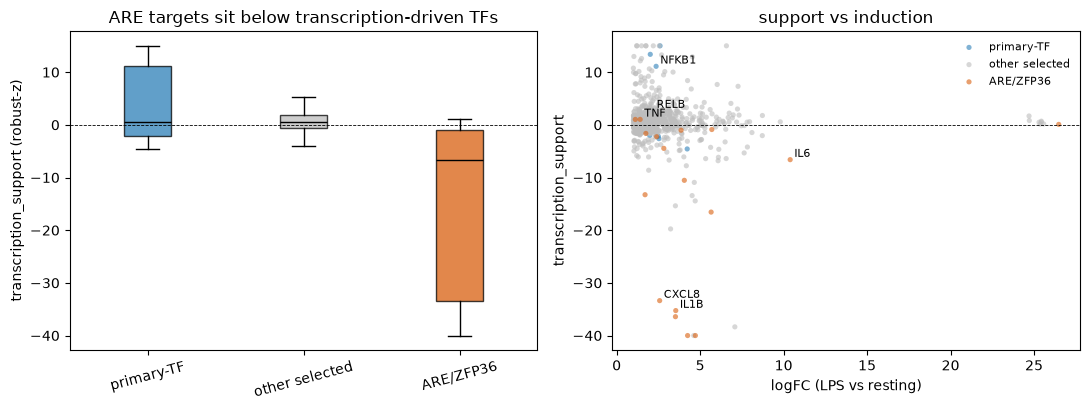

In [9]:
sel = res.selected
grp = np.where(sel.index.isin(ARE), "ARE/ZFP36",
      np.where(sel.index.isin(TXN), "primary-TF", "other selected"))
dfp = pd.DataFrame({"support": pd.to_numeric(sel["transcription_support"], errors="coerce"),
                    "logFC": pd.to_numeric(sel["logFC"], errors="coerce"),
                    "group": grp}).dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

order = ["primary-TF", "other selected", "ARE/ZFP36"]
colors = {"primary-TF": "#2c7fb8", "other selected": "#bdbdbd", "ARE/ZFP36": "#d95f0e"}
data = [dfp.loc[dfp.group == g, "support"].clip(-40, 15) for g in order]
bp = ax[0].boxplot(data, vert=True, patch_artist=True, showfliers=False,
                   medianprops=dict(color="black"))
for patch, g in zip(bp["boxes"], order):
    patch.set_facecolor(colors[g]); patch.set_alpha(0.75)
ax[0].set_xticklabels(order, rotation=15)
ax[0].axhline(0, color="k", lw=0.6, ls="--")
ax[0].set_ylabel("transcription_support (robust-z)")
ax[0].set_title("ARE targets sit below transcription-driven TFs")

for g in order:
    d = dfp[dfp.group == g]
    ax[1].scatter(d["logFC"], d["support"].clip(-40, 15), s=14, alpha=0.6,
                  c=colors[g], label=g, edgecolors="none")
for gname in ["IL1B", "CXCL8", "TNF", "IL6", "NFKB1", "RELB"]:
    if gname in dfp.index:
        r_ = dfp.loc[gname]
        ax[1].annotate(gname, (r_["logFC"], np.clip(r_["support"], -40, 15)),
                       fontsize=8, xytext=(3, 2), textcoords="offset points")
ax[1].axhline(0, color="k", lw=0.6, ls="--")
ax[1].set_xlabel("logFC (LPS vs resting)"); ax[1].set_ylabel("transcription_support")
ax[1].set_title("support vs induction"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 9. The DE step is pluggable

`de="builtin"` above reused scATrans' own DE pass. You can instead select the gene
list with **any** method — the partition/annotation is identical. Pass a
`de_method` name (routed to the package's multi-backend `differential_expression`:
t-test, Wilcoxon, PyDESeq2 pseudobulk, Memento, …), a **precomputed** DE table
(from edgeR / DESeq2 / scanpy — map the column names), or a callable.

In [10]:
# (a) a scanpy method name -> routed to differential_expression
res_tt = scat.partition_de_by_mechanism(
    adata, groupby="condition", target_group="LPS", reference_group="resting",
    organism="human", de="t-test",
)

# (b) a precomputed DE table (pretend it came from edgeR / DESeq2)
de_ext = pd.DataFrame(
    {"log2FC": pd.to_numeric(res.gene_table["logFC"], errors="coerce"),
     "FDR":    pd.to_numeric(res.gene_table["p_adj"], errors="coerce")},
    index=res.gene_table.index,
)
res_ext = scat.partition_de_by_mechanism(
    adata, groupby="condition", target_group="LPS", reference_group="resting",
    organism="human", de=de_ext, de_logfc_col="log2FC", de_padj_col="FDR",
)

print("selected genes  — builtin:", len(res.selected),
      "| t-test:", len(res_tt.selected),
      "| precomputed DF:", len(res_ext.selected))
print("de_source (t-test):", res_tt.meta["de_source"])
print("de_source (precomputed):", res_ext.meta["de_source"])

selected genes  — builtin: 718 | t-test: 1165 | precomputed DF: 718
de_source (t-test): differential_expression(t-test)
de_source (precomputed): dataframe


## 10. Limitations

- **Per-gene calls are low-confidence hints.** Prefer the **program** level;
  use per-gene labels only to prioritize, and read `mechanism_confidence`
  (scaled by the reliability pre-flight).
- **The proxy never removes DE hits.** Stabilization-driven genes remain DE
  members; annotate and rank, do not filter on the residual.
- **Down-regulation is not yet mechanism-resolved** (`unclassified_down`).
- **Detection ≠ mechanism.** `add_nascent_score=True` adds `nascent_poisson_z` /
  `de_reproducible` for detection annotations; mechanism labels stay residual-based.
- **Capture matters.** Low-capture or strongly 3′-biased data lower reliability
  and can flip per-gene direction—inspect `regime_diagnosis` first.

## Reproduce

The full data is GEO **GSE226488** (Derbois et al. 2023; BioProject PRJNA940428),
PBMC resting (GSM7077865) vs LPS-4h (GSM7077866), 10x 3′ v3.1.

```bash
# 1. FASTQ -> STARsolo (spliced/unspliced via Velocyto) -> assembled h5ad
bash   ~/cellranger/GSE226488_starsolo_pipeline.sh all
# writes GSE226488_work/GSE226488_PBMC_velocity.h5ad  (15449 x 62754)

# 2. downsample to the shippable tutorial subset used here (~4.4k cells)
python ~/cellranger/make_tutorial_subset.py
# -> GSE226488_PBMC_tutorial_subset.h5ad  (place at the repo root)
```

Everything above then runs against `../../GSE226488_PBMC_tutorial_subset.h5ad`.